# Exercise B.1 — Exploitation vs. Exploration and Population Diversity

This notebook runs all experiments for B.1 using a **string search genetic algorithm**.

**GA configuration:**
- Target string: `"NaturalComputing"` (L=16)
- Alphabet: 52 characters (a-z, A-Z)
- Tournament selection with parameter K
- Single-point crossover with p_c = 1
- Per-character mutation with rate mu
- Population size N = 200
- Generational replacement, no elitism

**Code structure:**
- `string_ga.py` — Core GA (selection, crossover, mutation, fitness, diversity metrics)
- `experiments_b1.py` — Experiment runners for each sub-exercise
- `plotting_b1.py` — Visualization functions (beeswarm, fitness curves, diversity, mu sweeps)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from experiments_b1 import (
    TARGET,
    experiment_b1_1,
    experiment_b1_2,
    experiment_b1_3,
    experiment_b1_5,
    experiment_b1_6,
)
from plotting_b1 import (
    plot_fitness_curves,
    plot_beeswarm,
    plot_diversity,
    plot_mu_vs_tfinish,
    plot_mu_sweep_comparison,
)

G_MAX = 100
N_RUNS = 10
L = len(TARGET)
print(f"Target: '{TARGET}' (L={L})")

Target: 'NaturalComputing' (L=16)


## B.1.1 — Baseline: K=2, mu=1/L

Run the GA 10 times and record `t_finish` (generation where the target is found).
We also plot the best-fitness curve for each run.

In [3]:
results_b1_1 = experiment_b1_1(n_runs=N_RUNS, G_max=G_MAX)

for r in results_b1_1:
    status = r['t_finish'] if r['t_finish'] is not None else f"not found in {G_MAX}"
    print(f"  Run {r['run']}: t_finish = {status}")

  Run 1/10: t_finish = 66
  Run 2/10: t_finish = 75
  Run 3/10: t_finish = 75
  Run 4/10: t_finish = 58
  Run 5/10: t_finish = 46
  Run 6/10: t_finish = 77
  Run 7/10: t_finish = 39
  Run 8/10: t_finish = 68
  Run 9/10: t_finish = 70
  Run 10/10: t_finish = 41
  Run 0: t_finish = 66
  Run 1: t_finish = 75
  Run 2: t_finish = 75
  Run 3: t_finish = 58
  Run 4: t_finish = 46
  Run 5: t_finish = 77
  Run 6: t_finish = 39
  Run 7: t_finish = 68
  Run 8: t_finish = 70
  Run 9: t_finish = 41


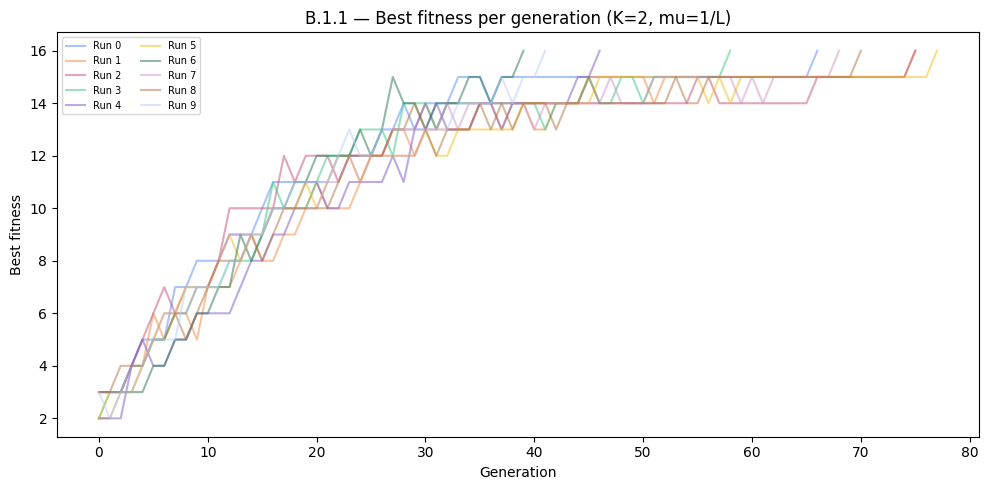

In [4]:
fig = plot_fitness_curves(results_b1_1, title="B.1.1 — Best fitness per generation (K=2, mu=1/L)")
plt.show()

## B.1.2 — Effect of mutation rate: mu=0, mu=1/L, mu=3/L

Compare three mutation rates with K=2. For mu=0 the GA relies purely on crossover and selection.
We cap each run at G_max=100 generations.

The beeswarm plot shows the distribution of `t_finish` across runs; red X marks indicate the target was not found within G_max.

In [5]:
results_b1_2 = experiment_b1_2(n_runs=N_RUNS, G_max=G_MAX)

  Running mu=0...
    Found target in 0/10 runs
  Running mu=1/L...
    Found target in 10/10 runs
  Running mu=3/L...
    Found target in 0/10 runs


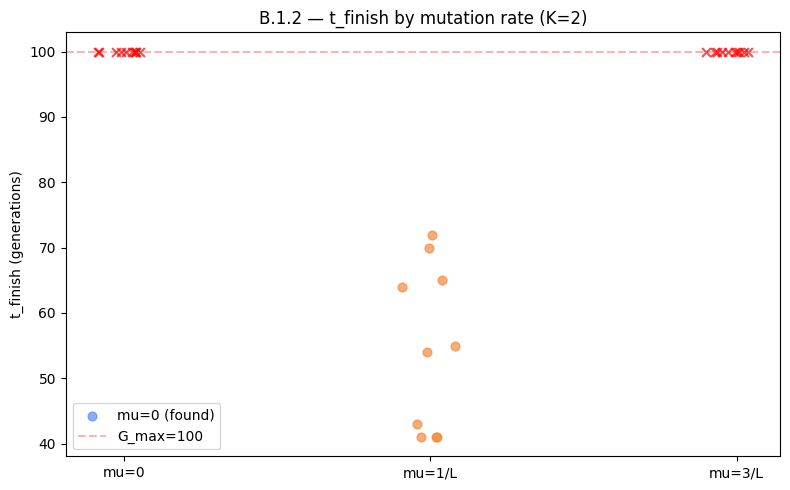

In [6]:
fig = plot_beeswarm(results_b1_2, G_max=G_MAX, title="B.1.2 — t_finish by mutation rate (K=2)")
plt.show()

## B.1.3 — Population diversity analysis

Rerun the three mutation-rate configurations while tracking diversity every 10 generations.

Diversity is measured two ways (see Appendix of the assignment):
- **Mean Shannon entropy** across all string positions — higher = more diverse
- **Mean pairwise Hamming distance** — higher = individuals are more different from each other

In [7]:
results_b1_3 = experiment_b1_3(n_runs=N_RUNS, G_max=G_MAX)

  Running mu=0 with diversity tracking...
    Found target in 1/10 runs
  Running mu=1/L with diversity tracking...
    Found target in 10/10 runs
  Running mu=3/L with diversity tracking...
    Found target in 0/10 runs


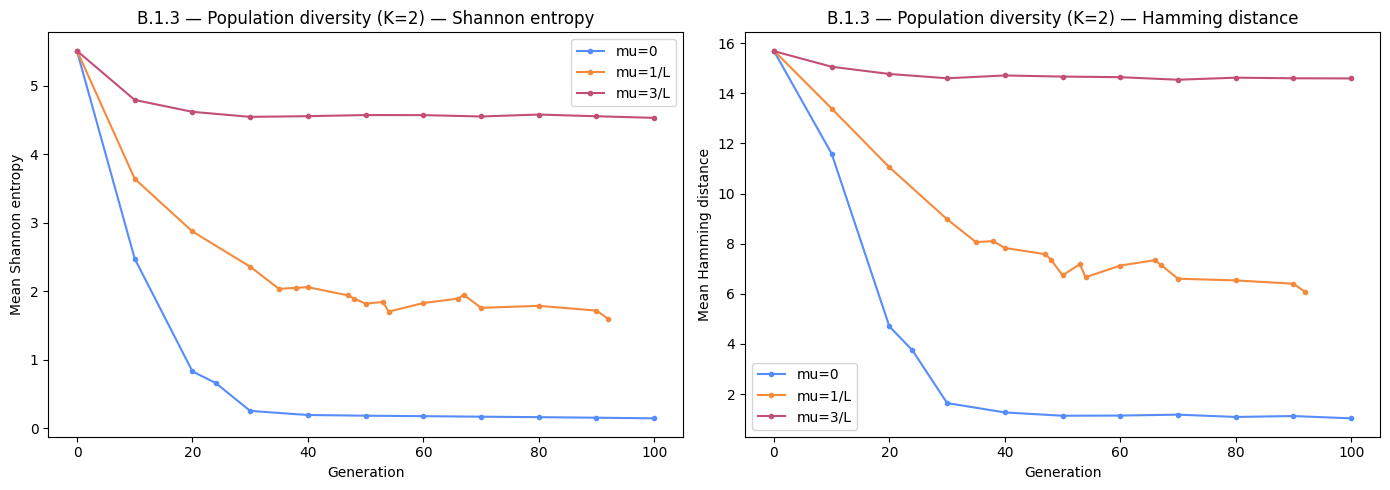

In [8]:
fig = plot_diversity(results_b1_3, title_prefix="B.1.3 — Population diversity (K=2)")
plt.show()

## B.1.4 — Discussion: influence of mu on performance and diversity

Observations from B.1.2 and B.1.3 are discussed in the report. Key points:

- **mu=0**: Without mutation, the GA cannot introduce new genetic material. Crossover alone can only recombine existing alleles. Once diversity is lost at a position, it cannot be recovered — the population converges prematurely and gets stuck.
- **mu=1/L**: Moderate mutation maintains diversity and allows the GA to escape local optima while still converging. This is the standard recommended rate.
- **mu=3/L**: Higher mutation increases exploration but can slow convergence by disrupting good partial solutions.

## B.1.5 — Sweep mu from 0 to 10/L, find optimal mu (K=2)

We gradually increase mu and measure t_finish to find the sweet spot.

In [9]:
results_b1_5 = experiment_b1_5(n_runs=N_RUNS, G_max=G_MAX)

  Running mu = 0.0/L...
    Found target in 1/10 runs
  Running mu = 1.0/L...
    Found target in 10/10 runs
  Running mu = 2.0/L...
    Found target in 0/10 runs
  Running mu = 3.0/L...
    Found target in 0/10 runs
  Running mu = 4.0/L...
    Found target in 0/10 runs
  Running mu = 5.0/L...
    Found target in 0/10 runs
  Running mu = 6.0/L...
    Found target in 0/10 runs
  Running mu = 7.0/L...
    Found target in 0/10 runs
  Running mu = 8.0/L...
    Found target in 0/10 runs
  Running mu = 9.0/L...
    Found target in 0/10 runs
  Running mu = 10.0/L...
    Found target in 0/10 runs


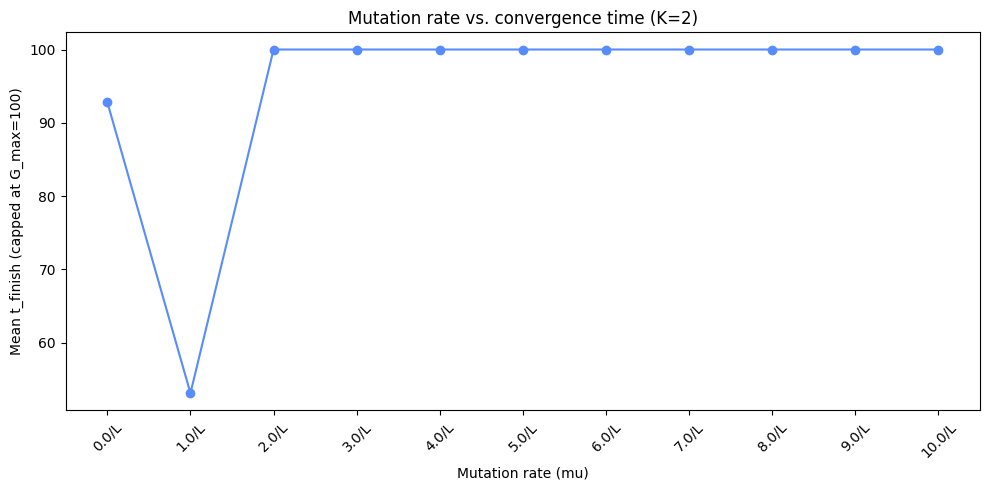

In [10]:
fig = plot_mu_vs_tfinish(results_b1_5, G_max=G_MAX, L=L, K_label="K=2")
plt.show()

## B.1.6 — Repeat with K=5

Higher tournament size increases selection pressure. We repeat the mu sweep to see how this interacts with mutation rate.

In [11]:
results_b1_6 = experiment_b1_6(n_runs=N_RUNS, G_max=G_MAX)

  Running mu = 0.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 1.0/L (K=5)...
    Found target in 10/10 runs
  Running mu = 2.0/L (K=5)...
    Found target in 10/10 runs
  Running mu = 3.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 4.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 5.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 6.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 7.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 8.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 9.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 10.0/L (K=5)...
    Found target in 0/10 runs


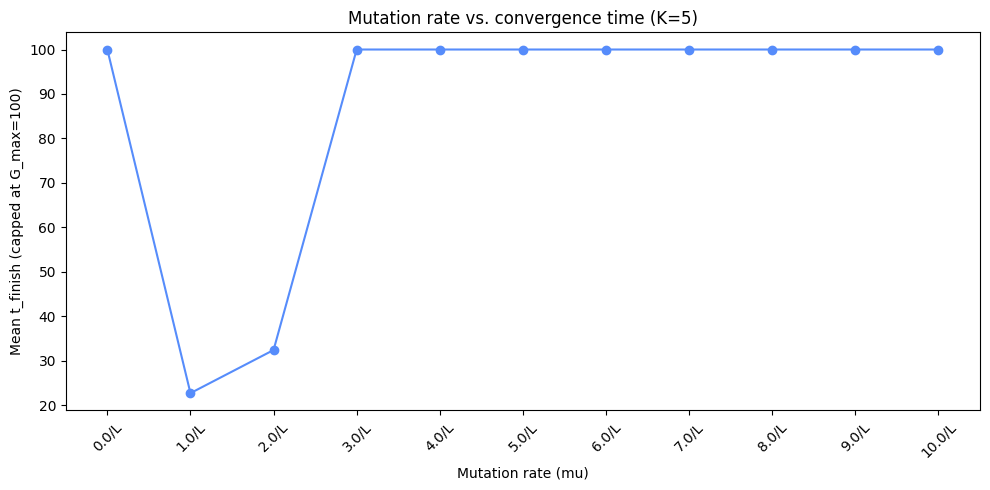

In [12]:
fig = plot_mu_vs_tfinish(results_b1_6, G_max=G_MAX, L=L, K_label="K=5")
plt.show()

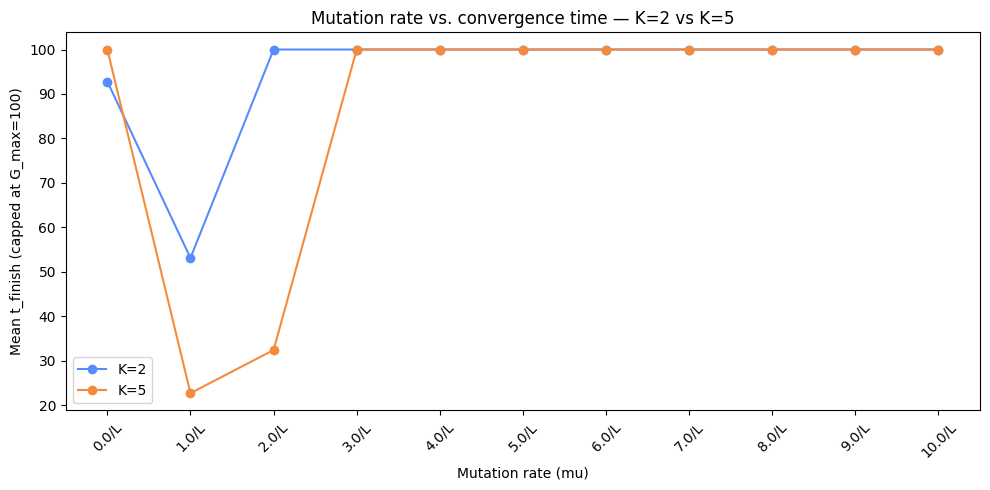

In [13]:
fig = plot_mu_sweep_comparison(results_b1_5, results_b1_6, G_max=G_MAX, L=L)
plt.show()